## Librerias

In [1]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [3]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [4]:
# Cuantos partidos se jugaron?
# Completar : 64
mundial.shape


(64, 59)

In [5]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar

mundial.columns


Index(['match_no', 'day_of_week', 'date', 'hour', 'venue', 'referee', 'group',
       '1', '2', 'attendance', '1_xg', '2_xg', '1_poss', '2_poss', '1_goals',
       '2_goals', 'score', '1_attempts', '2_attempts', '1_conceded',
       '2_conceded', '1_goal_inside_penalty_area',
       '2_goal_inside_penalty_area', '1_goal_outside_penalty_area',
       '2_goal_outside_penalty_area', '1_ontarget', '2_ontarget',
       '1_offtarget', '2_offtarget', '1_attempts_inside_penalty_area',
       '2_attempts_inside_penalty_area', '1_attempts_outside_penalty_area',
       '2_attempts_outside_penalty_area', '1_yellow_cards', '2_yellow_cards',
       '1_red_cards', '2_red_cards', 'faul_against_1', 'faul_against_2',
       '1_offsides', '2_offsides', '1_passes', '2_passes',
       '1_passes_compeletd', '2_passes_compeletd', '1_corners', '2_corners',
       '1_free_kicks', '2_free_kicks', '1_panelties_scored',
       '2_panelties_scored', '1_goal_prevented', '2_goal_prevented',
       '1_own_goal', '2_o

## Analisis

### Primera Parte

In [6]:
# Cuantas selecciones participaron?
# Completar
all_teams = pd.concat([mundial['1'], mundial['2']]).unique()
num_participating_teams = len(all_teams)
num_participating_teams

32

In [7]:
# Cuantas fases tiene el mundial?
# Completar
phases = mundial['group'].unique()

normalized_phases = [('Group Stage' if phase.startswith('Group') else phase) for phase in phases]
num_phases = len(pd.Series(normalized_phases).unique())
print(f"El mundial tiene {num_phases} fases (considerando todas las fases de grupo como una sola).")

El mundial tiene 6 fases (considerando todas las fases de grupo como una sola).


In [8]:
# Cual fue la "attendance" promedio por partido?
# Completar
attendance_mean = mundial['attendance'].mean()
attendance_mean

np.float64(53191.4375)

In [9]:
# Cual fue el partido con mas diferencia de goles?
# Completar
mundial['goal_difference'] = (mundial['1_goals'] - mundial['2_goals']).abs()
max_goal_diff = mundial['goal_difference'].max()
max_goal_diff_row = mundial.loc[mundial['goal_difference'] == max_goal_diff]
display(max_goal_diff_row)

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied,goal_difference
10,11,Wed,23-Nov-22,17:00,Al Thumama Stadium,Mohammed Abdulla Hassan,Group E,SPAIN,COSTA RICA,40013,...,0,0,17,0,0,46,76,185,585,7


In [10]:
# Cual es la selección que mas penales metió?
# Completar
penalties_team1 = mundial.groupby('1')['1_panelties_scored'].sum()
penalties_team2 = mundial.groupby('2')['2_panelties_scored'].sum()

all_penalties = penalties_team1.add(penalties_team2, fill_value=0)
most_penalties_team = all_penalties.idxmax()
max_penalties_count = all_penalties.max()

print(f"{most_penalties_team}")

ARGENTINA


In [11]:
# Cual es la selección que mas penales le hicieron?
# Completar
penalties_received_team1 = mundial.groupby('1')['2_panelties_scored'].sum()
penalties_received_team2 = mundial.groupby('2')['1_panelties_scored'].sum()
max_penalties_received = penalties_received_team1.add(penalties_received_team2, fill_value=0).max()
max_penalties_received_team = penalties_received_team1.add(penalties_received_team2, fill_value=0).idxmax()
print(f"{max_penalties_received_team}")

FRANCE


### Segunda Parte

In [12]:
equipo : str = "ARGENTINA"

In [13]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

equipo : str = "ARGENTINA"

filtroLocal : pd.Series = mundial["1"] == equipo
num_partidos_local = mundial[filtroLocal]
cantidad_partidos_local = len(num_partidos_local)
print(num_partidos_local[["match_no", "1","2"]])
print(f"La cantidad de partidos de local es de: {cantidad_partidos_local}")

    match_no          1             2
4          5  ARGENTINA  SAUDI ARABIA
23        24  ARGENTINA        MEXICO
49        50  ARGENTINA     AUSTRALIA
60        61  ARGENTINA       CROATIA
63        64  ARGENTINA        FRANCE
La cantidad de partidos de local es de: 5


In [27]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

equipo : str = "ARGENTINA"

filtroVisitante : pd.Series = mundial["2"] == equipo
num_partidos_visitante = mundial[filtroVisitante]
cantidad_partidos_visitante= len(num_partidos_visitante)
print(num_partidos_visitante[["match_no", "1","2"]])
print(f"La cantidad de partidos de visitante es de: {cantidad_partidos_visitante}")

    match_no            1          2
38        39       POLAND  ARGENTINA
57        58  NETHERLANDS  ARGENTINA
La cantidad de partidos de visitante es de: 2


In [15]:
# Cuantos partidos jugó el equipo?
# Completar
equipo : str = "ARGENTINA"

partidos : pd.Series = (mundial["1"] == equipo) | (mundial["2"] == equipo)
num_partidos_equipo = mundial[partidos]
cantidad_partidos_equipo = len(num_partidos_equipo)
print(num_partidos_equipo[['match_no', '1', '2']])
print(f"La cantidad total de partidos del equipo es de: {cantidad_partidos_equipo}")

    match_no            1             2
4          5    ARGENTINA  SAUDI ARABIA
23        24    ARGENTINA        MEXICO
38        39       POLAND     ARGENTINA
49        50    ARGENTINA     AUSTRALIA
57        58  NETHERLANDS     ARGENTINA
60        61    ARGENTINA       CROATIA
63        64    ARGENTINA        FRANCE
La cantidad total de partidos del equipo es de: 7


In [16]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles_local = num_partidos_equipo[num_partidos_equipo['1'] == equipo]['1_goals'].sum()
goles_visitante = num_partidos_equipo[num_partidos_equipo['2'] == equipo]['2_goals'].sum()
goles : int = goles_local + goles_visitante
goles

np.int64(15)

In [17]:
# Cuantos goles hizo el equipo en promedio
# Completar
goles_promedio = goles / cantidad_partidos_equipo
print(f"{goles_promedio}"
)

2.142857142857143


In [18]:
# Cuantos partidos gano el equipo
# Completar

ganados_local = ((num_partidos_equipo['1'] == equipo) & (num_partidos_equipo['1_goals'] > num_partidos_equipo['2_goals'])).sum()
ganados_visitante = ((num_partidos_equipo['2'] == equipo) & (num_partidos_equipo['2_goals'] > num_partidos_equipo['1_goals'])).sum()
ganados : int = ganados_local + ganados_visitante
print(f"{ganados}")

4


/tmp/ipykernel_12258/3613173952.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  num_partidos_equipo['team_goals'] = num_partidos_equipo.apply(lambda row:


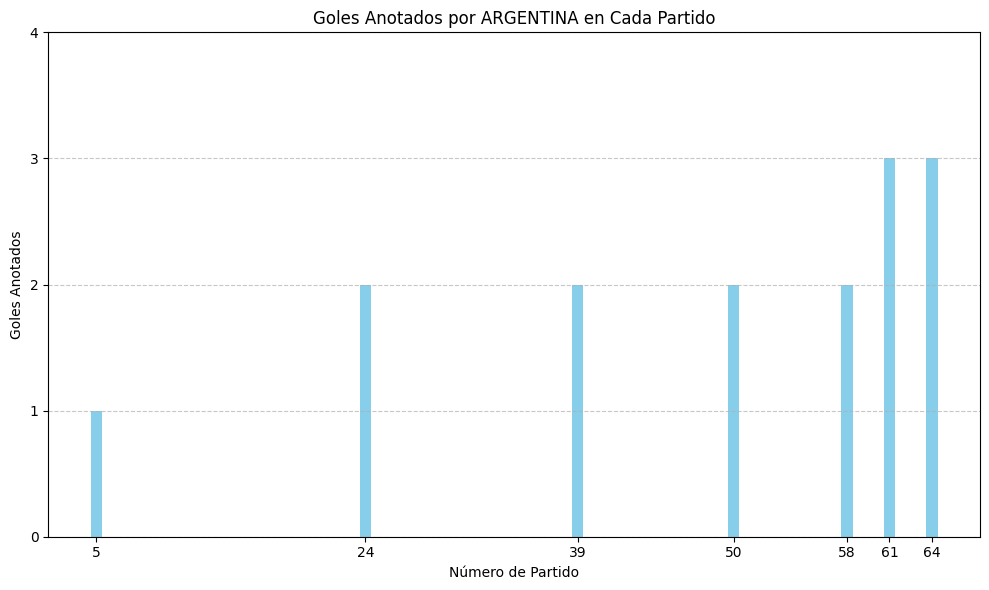

In [19]:
# Graficar los goles hechos por el equipo en cada partido

fig, ax = plt.subplots(figsize=(10, 6))
 #completar
num_partidos_equipo['team_goals'] = num_partidos_equipo.apply(lambda row:
    row['1_goals'] if row['1'] == equipo else row['2_goals'], axis=1
)
ax.bar(num_partidos_equipo['match_no'], num_partidos_equipo['team_goals'], color='skyblue')


ax.set_xlabel('Número de Partido')
ax.set_ylabel('Goles Anotados')
ax.set_title(f'Goles Anotados por {equipo} en Cada Partido')
ax.set_xticks(num_partidos_equipo['match_no'])
ax.set_yticks(range(int(num_partidos_equipo['team_goals'].max()) + 2))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Tercera Parte

In [20]:
#contar cuantos goles hizo cada equipo en total en el mundial
# Completar
goles_local = mundial.groupby('1')['1_goals'].sum()
goles_visitante = mundial.groupby('2')['2_goals'].sum()
goles_combinados = goles_local.add(goles_visitante, fill_value=0).astype(int)
tabla_goles = goles_combinados.reset_index()
tabla_goles.columns = ['Equipo', 'Goles Totales']
tabla_goles = tabla_goles.sort_values(by='Goles Totales', ascending=False)

print(tabla_goles)

            Equipo  Goles Totales
11          FRANCE             16
0        ARGENTINA             15
10         ENGLAND             13
21        PORTUGAL             12
19     NETHERLANDS             10
26           SPAIN              9
7          CROATIA              8
3           BRAZIL              8
18         MOROCCO              6
12         GERMANY              6
25          SERBIA              5
27     SWITZERLAND              5
16  KOREA REPUBLIC              5
24         SENEGAL              5
13           GHANA              5
15           JAPAN              5
4         CAMEROON              4
14            IRAN              4
9          ECUADOR              4
1        AUSTRALIA              4
29   UNITED STATES              3
23    SAUDI ARABIA              3
20          POLAND              3
6       COSTA RICA              3
30         URUGUAY              2
17          MEXICO              2
5           CANADA              2
2          BELGIUM              1
8          DEN

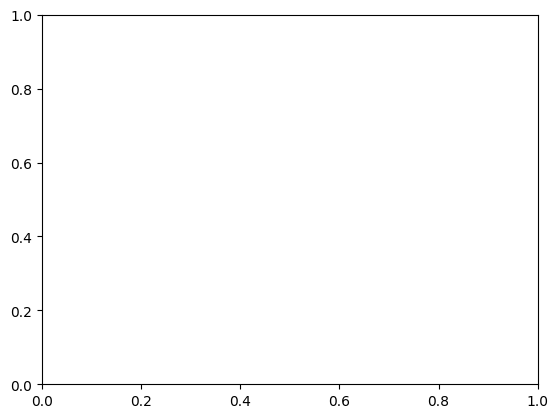

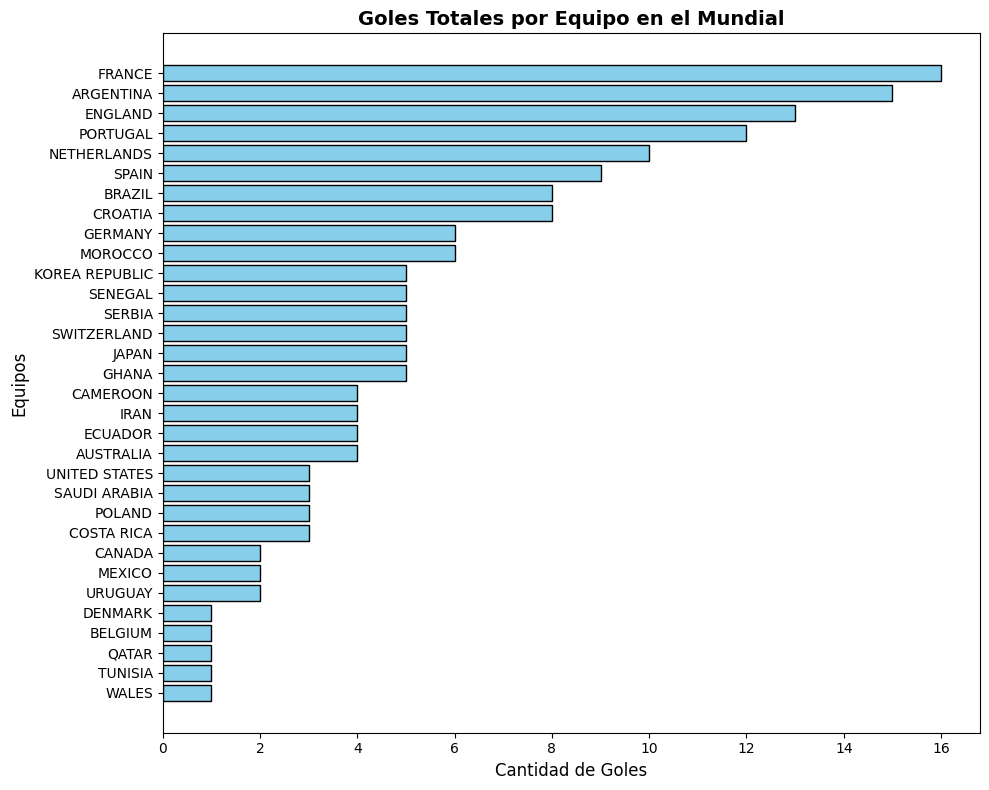

In [21]:
# Graficar los goles por equipo en todo el mundial

fig, ax = plt.subplots()
# Completar
goles_local = mundial.groupby('1')['1_goals'].sum()
goles_visitante = mundial.groupby('2')['2_goals'].sum()
goles_combinados = goles_local.add(goles_visitante, fill_value=0).astype(int)
tabla_goles = goles_combinados.reset_index()
tabla_goles.columns = ['Equipo', 'Goles Totales']
tabla_goles = tabla_goles.sort_values(by='Goles Totales', ascending=False)
tabla_grafico = tabla_goles.sort_values(by='Goles Totales', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(tabla_grafico['Equipo'], tabla_grafico['Goles Totales'], color='skyblue', edgecolor='black')


ax.set_title('Goles Totales por Equipo en el Mundial', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Goles', fontsize=12)
ax.set_ylabel('Equipos', fontsize=12)


plt.tight_layout()
plt.show()

In [22]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar
goles_1 = mundial.groupby('1')['1_goals'].sum()
goles_2 = mundial.groupby('2')['2_goals'].sum()
goles_totales = goles_1.add(goles_2, fill_value=0)
equipo_con_mas_goles = goles_totales.idxmax()
cantidad_goles = goles_totales.max()

print(f"El equipo que hizo más goles en el mundial es: {equipo_con_mas_goles} con {cantidad_goles} goles.")

El equipo que hizo más goles en el mundial es: FRANCE con 16 goles.


In [23]:
# Por cada partido, cual fue la diferencia de goles?
# Completar
deferencia_goles_por_partido = mundial['1_goals']-mundial['2_goals']
if deferencia_goles_por_partido.min() < 0:
    deferencia_goles_por_partido = deferencia_goles_por_partido.abs()
print( deferencia_goles_por_partido)

0     2
1     4
2     2
3     0
4     1
     ..
59    1
60    3
61    2
62    1
63    0
Length: 64, dtype: int64


In [24]:
# Por cada partido, cual fue el equipo que gano?
# Completar
def obtener_ganador_con_penales(row):
    if row['1_goals'] > row['2_goals']:
        return row['1']

    elif row['2_goals'] > row['1_goals']:
        return row['2']
    else:
        if row['1_panelties_scored'] > row['2_panelties_scored']:
            return row['1']
        elif row['2_panelties_scored'] > row['1_panelties_scored']:
            return row['2']
        else:
            return "Empate"


equipo_ganador_del_partido = mundial.apply(obtener_ganador_con_penales, axis=1)

print(equipo_ganador_del_partido)

0          ECUADOR
1          ENGLAND
2      NETHERLANDS
3            WALES
4     SAUDI ARABIA
          ...     
59          FRANCE
60       ARGENTINA
61          FRANCE
62         CROATIA
63          FRANCE
Length: 64, dtype: object


In [25]:

# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# completar



goles_local = mundial.groupby(['group', '1'])['1_goals'].sum().rename_axis(['Fase', 'Equipo'])
goles_vis = mundial.groupby(['group', '2'])['2_goals'].sum().rename_axis(['Fase', 'Equipo'])

totales_fase = goles_local.add(goles_vis, fill_value=0).astype(int).reset_index()
totales_fase.columns = ['Fase', 'Equipo', 'Goles Totales']

indices_maximos = totales_fase.groupby('Fase')['Goles Totales'].idxmax()
equipo_mas_goles_por_fase = totales_fase.loc[indices_maximos].sort_values(by='Fase')

print(equipo_mas_goles_por_fase[['Fase', 'Equipo']].to_string(index=False))


                    Fase      Equipo
                   Final   ARGENTINA
                 Group A NETHERLANDS
                 Group B     ENGLAND
                 Group C   ARGENTINA
                 Group D      FRANCE
                 Group E       SPAIN
                 Group F     CROATIA
                 Group G      SERBIA
                 Group H    PORTUGAL
Play-off for third place     CROATIA
           Quarter-final   ARGENTINA
             Round of 16    PORTUGAL
              Semi-Final   ARGENTINA


### Tercera Parte

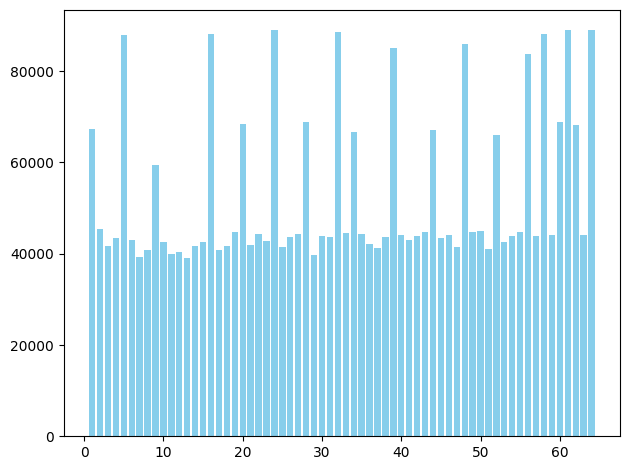

In [26]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar

#armar el grafico que muestra los partidos de mayor a menor attendance
fig, ax = plt.subplots()
# Completar
attendance = mundial.sort_values(by='attendance', ascending=False)
ax.bar(attendance['match_no'], attendance['attendance'], color='skyblue')



plt.tight_layout()
plt.show()